# Análisis de etiquetas POS y dependencias sintácticas con spaCy

## Grupo 1: Fundamentos lingüísticos y niveles del lenguaje

Este notebook implementa un análisis de procesamiento de lenguaje natural
sobre un conjunto controlado de oraciones en español.

Se utiliza spaCy para obtener información léxica, morfológica y sintáctica
de cada token, con énfasis en:

- etiquetado de categorías gramaticales POS;
- lematización;
- características morfológicas;
- relaciones de dependencia sintáctica;
- identificación de la cabeza sintáctica de cada token;
- visualización de dependencias.

In [1]:
!pip install -q spacy pandas

In [2]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 63.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Configuración del entorno

Para garantizar la reproducibilidad del análisis se registran las versiones
de Python, spaCy, pandas y el modelo lingüístico empleado.

In [3]:
import sys
import spacy
import pandas as pd
import importlib.metadata

nlp = spacy.load("es_core_news_sm")

print("Python:", sys.version.split()[0])
print("spaCy:", spacy.__version__)
print("pandas:", pd.__version__)
print(
    "es_core_news_sm:",
    importlib.metadata.version("es-core-news-sm")
)

Python: 3.13.15
spaCy: 3.8.16
pandas: 2.2.3
es_core_news_sm: 3.8.0


## Corpus de análisis

Se utiliza un corpus didáctico controlado compuesto por trece oraciones
en español. Las oraciones fueron seleccionadas para representar estructuras
lingüísticas de diferente complejidad, incluyendo categorías gramaticales,
modificadores, coordinación, subordinación y casos de ambigüedad lingüística.

In [4]:
oraciones = [
    "La estudiante resuelve el ejercicio.",
    "El investigador analiza cuidadosamente los resultados.",
    "Los modelos lingüísticos procesan textos en español.",
    "María entregó el informe al profesor.",
    "Ellos revisaron rápidamente las referencias bibliográficas.",
    "El sistema identifica palabras y relaciones sintácticas.",
    "La profesora que dirige el proyecto explicó la metodología.",
    "Cuando terminó la clase, los estudiantes enviaron sus tareas.",
    "Aunque el texto era breve, contenía varias estructuras complejas.",
    "El estudiante dijo que el modelo reconoció correctamente el verbo.",
    "El banco aprobó el crédito solicitado por la empresa.",
    "Los estudiantes se sentaron en el banco del parque.",
    "María observó al profesor con los binoculares."
]

print("Número total de oraciones:", len(oraciones))

Número total de oraciones: 13


In [5]:
for i, oracion in enumerate(oraciones, start=1):
    print(f"O{i}: {oracion}")

O1: La estudiante resuelve el ejercicio.
O2: El investigador analiza cuidadosamente los resultados.
O3: Los modelos lingüísticos procesan textos en español.
O4: María entregó el informe al profesor.
O5: Ellos revisaron rápidamente las referencias bibliográficas.
O6: El sistema identifica palabras y relaciones sintácticas.
O7: La profesora que dirige el proyecto explicó la metodología.
O8: Cuando terminó la clase, los estudiantes enviaron sus tareas.
O9: Aunque el texto era breve, contenía varias estructuras complejas.
O10: El estudiante dijo que el modelo reconoció correctamente el verbo.
O11: El banco aprobó el crédito solicitado por la empresa.
O12: Los estudiantes se sentaron en el banco del parque.
O13: María observó al profesor con los binoculares.


In [6]:
oracion_prueba = oraciones[0]

doc = nlp(oracion_prueba)

print("Oración analizada:")
print(oracion_prueba)

Oración analizada:
La estudiante resuelve el ejercicio.


In [7]:
for token in doc:
    print(token.text)

La
estudiante
resuelve
el
ejercicio
.


In [8]:
for token in doc:
    print(token.text, "→", token.pos_)

La → DET
estudiante → NOUN
resuelve → VERB
el → DET
ejercicio → NOUN
. → PUNCT


In [9]:
for token in doc:
    print(
        token.text,
        "| POS:", token.pos_,
        "| DEP:", token.dep_,
        "| HEAD:", token.head.text
    )

La | POS: DET | DEP: det | HEAD: estudiante
estudiante | POS: NOUN | DEP: nsubj | HEAD: resuelve
resuelve | POS: VERB | DEP: ROOT | HEAD: resuelve
el | POS: DET | DEP: det | HEAD: ejercicio
ejercicio | POS: NOUN | DEP: obj | HEAD: resuelve
. | POS: PUNCT | DEP: punct | HEAD: resuelve


In [10]:
for token in doc:
    print(
        token.text,
        "| Lema:", token.lemma_,
        "| POS:", token.pos_,
        "| Morfología:", token.morph,
        "| Dependencia:", token.dep_,
        "| Cabeza:", token.head.text
    )

La | Lema: el | POS: DET | Morfología: Definite=Def|Gender=Fem|Number=Sing|PronType=Art | Dependencia: det | Cabeza: estudiante
estudiante | Lema: estudiante | POS: NOUN | Morfología: Number=Sing | Dependencia: nsubj | Cabeza: resuelve
resuelve | Lema: resolver | POS: VERB | Morfología: Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin | Dependencia: ROOT | Cabeza: resuelve
el | Lema: el | POS: DET | Morfología: Definite=Def|Gender=Masc|Number=Sing|PronType=Art | Dependencia: det | Cabeza: ejercicio
ejercicio | Lema: ejercicio | POS: NOUN | Morfología: Gender=Masc|Number=Sing | Dependencia: obj | Cabeza: resuelve
. | Lema: . | POS: PUNCT | Morfología: PunctType=Peri | Dependencia: punct | Cabeza: resuelve


## Procesamiento del corpus

Cada oración del corpus se procesa mediante el pipeline lingüístico de spaCy.
Para cada token se extraen el lema, la categoría gramatical POS, los rasgos
morfológicos, la relación de dependencia sintáctica y su cabeza sintáctica.

In [11]:
import pandas as pd

resultados = []

for i, oracion in enumerate(oraciones, start=1):
    doc = nlp(oracion)

    for token in doc:
        resultados.append({
            "oracion_id": f"O{i}",
            "oracion": oracion,
            "token": token.text,
            "lema": token.lemma_,
            "pos": token.pos_,
            "morfologia": str(token.morph),
            "dependencia": token.dep_,
            "cabeza": token.head.text
        })

df_resultados = pd.DataFrame(resultados)

print("Número de registros generados:", len(df_resultados))
df_resultados.head(20)

Número de registros generados: 114


,oracion_id,oracion,token,lema,pos,morfologia,dependencia,cabeza
0,O1,La estudiante resuelve el ejercicio.,La,el,DET,Definite=Def|Gender=Fem|Number=Sing|PronType=Art,det,estudiante
1,O1,La estudiante resuelve el ejercicio.,estudiante,estudiante,NOUN,Number=Sing,nsubj,resuelve
2,O1,La estudiante resuelve el ejercicio.,resuelve,resolver,VERB,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbF...,ROOT,resuelve
3,O1,La estudiante resuelve el ejercicio.,el,el,DET,Definite=Def|Gender=Masc|Number=Sing|PronType=Art,det,ejercicio
4,O1,La estudiante resuelve el ejercicio.,ejercicio,ejercicio,NOUN,Gender=Masc|Number=Sing,obj,resuelve
5,O1,La estudiante resuelve el ejercicio.,.,.,PUNCT,PunctType=Peri,punct,resuelve
6,O2,El investigador analiza cuidadosamente los res...,El,el,DET,Definite=Def|Gender=Masc|Number=Sing|PronType=Art,det,investigador
7,O2,El investigador analiza cuidadosamente los res...,investigador,investigador,NOUN,Gender=Masc|Number=Sing,nsubj,analiza
8,O2,El investigador analiza cuidadosamente los res...,analiza,analizar,VERB,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbF...,ROOT,analiza
9,O2,El investigador analiza cuidadosamente los res...,cuidadosamente,cuidadosamente,ADV,,advmod,analiza


In [12]:
print("Oraciones procesadas:")
print(df_resultados["oracion_id"].unique())

print("\nNúmero de oraciones:")
print(df_resultados["oracion_id"].nunique())

Oraciones procesadas:
['O1' 'O2' 'O3' 'O4' 'O5' 'O6' 'O7' 'O8' 'O9' 'O10' 'O11' 'O12' 'O13']

Número de oraciones:
13


In [13]:
df_resultados[
    df_resultados["oracion_id"] == "O1"
][[
    "token",
    "lema",
    "pos",
    "morfologia",
    "dependencia",
    "cabeza"
]]

,token,lema,pos,morfologia,dependencia,cabeza
0,La,el,DET,Definite=Def|Gender=Fem|Number=Sing|PronType=Art,det,estudiante
1,estudiante,estudiante,NOUN,Number=Sing,nsubj,resuelve
2,resuelve,resolver,VERB,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbF...,ROOT,resuelve
3,el,el,DET,Definite=Def|Gender=Masc|Number=Sing|PronType=Art,det,ejercicio
4,ejercicio,ejercicio,NOUN,Gender=Masc|Number=Sing,obj,resuelve
5,.,.,PUNCT,PunctType=Peri,punct,resuelve


## Distribución de categorías gramaticales

Se contabilizan las etiquetas POS asignadas por spaCy a los tokens del corpus.
Para el resumen se excluyen los signos de puntuación, ya que el interés
principal se centra en las categorías léxicas y gramaticales.

In [14]:
df_sin_puntuacion = df_resultados[
    df_resultados["pos"] != "PUNCT"
].copy()

resumen_pos = (
    df_sin_puntuacion["pos"]
    .value_counts()
    .reset_index()
)

resumen_pos.columns = ["POS", "Frecuencia"]

resumen_pos

,POS,Frecuencia
0,NOUN,32
1,DET,25
2,VERB,16
3,ADP,7
4,ADJ,6
5,ADV,3
6,PRON,3
7,SCONJ,3
8,PROPN,2
9,CCONJ,1


In [15]:
resumen_pos["Porcentaje"] = (
    resumen_pos["Frecuencia"]
    / resumen_pos["Frecuencia"].sum()
    * 100
).round(2)

resumen_pos

,POS,Frecuencia,Porcentaje
0,NOUN,32,32.32
1,DET,25,25.25
2,VERB,16,16.16
3,ADP,7,7.07
4,ADJ,6,6.06
5,ADV,3,3.03
6,PRON,3,3.03
7,SCONJ,3,3.03
8,PROPN,2,2.02
9,CCONJ,1,1.01


## Distribución de relaciones de dependencia

Se contabilizan las relaciones sintácticas identificadas por el analizador
de dependencias de spaCy. Para este resumen también se excluye la puntuación.

In [16]:
resumen_dependencias = (
    df_sin_puntuacion["dependencia"]
    .value_counts()
    .reset_index()
)

resumen_dependencias.columns = [
    "Dependencia",
    "Frecuencia"
]

resumen_dependencias["Porcentaje"] = (
    resumen_dependencias["Frecuencia"]
    / resumen_dependencias["Frecuencia"].sum()
    * 100
).round(2)

resumen_dependencias

,Dependencia,Frecuencia,Porcentaje
0,det,25,25.25
1,nsubj,16,16.16
2,obj,14,14.14
3,ROOT,13,13.13
4,case,7,7.07
5,amod,5,5.05
6,advmod,3,3.03
7,nmod,3,3.03
8,mark,3,3.03
9,obl,2,2.02


In [17]:
tokens_por_oracion = (
    df_resultados
    .groupby("oracion_id")
    .size()
    .reset_index(name="numero_tokens")
)

tokens_por_oracion

,oracion_id,numero_tokens
0,O1,6
1,O10,11
2,O11,10
3,O12,10
4,O13,8
5,O2,7
6,O3,8
7,O4,7
8,O5,7
9,O6,8


In [18]:
tokens_linguisticos_por_oracion = (
    df_sin_puntuacion
    .groupby("oracion_id")
    .size()
    .reset_index(name="numero_tokens_sin_puntuacion")
)

tokens_linguisticos_por_oracion

,oracion_id,numero_tokens_sin_puntuacion
0,O1,5
1,O10,10
2,O11,9
3,O12,9
4,O13,7
5,O2,6
6,O3,7
7,O4,6
8,O5,6
9,O6,7


In [19]:
total_oraciones = df_resultados["oracion_id"].nunique()
total_tokens = len(df_resultados)
total_tokens_sin_puntuacion = len(df_sin_puntuacion)
total_pos = df_sin_puntuacion["pos"].nunique()
total_dependencias = df_sin_puntuacion["dependencia"].nunique()

print("RESUMEN DEL CORPUS")
print("-------------------")
print("Oraciones:", total_oraciones)
print("Tokens totales:", total_tokens)
print("Tokens sin puntuación:", total_tokens_sin_puntuacion)
print("Categorías POS diferentes:", total_pos)
print("Dependencias diferentes:", total_dependencias)

RESUMEN DEL CORPUS
-------------------
Oraciones: 13
Tokens totales: 114
Tokens sin puntuación: 99
Categorías POS diferentes: 11
Dependencias diferentes: 17


In [20]:
df_resultados[
    df_resultados["oracion_id"].isin(["O11", "O12"])
][[
    "oracion_id",
    "token",
    "lema",
    "pos",
    "dependencia",
    "cabeza"
]]

,oracion_id,token,lema,pos,dependencia,cabeza
86,O11,El,el,DET,det,banco
87,O11,banco,banco,NOUN,nsubj,aprobó
88,O11,aprobó,aprobar,VERB,ROOT,aprobó
89,O11,el,el,DET,det,crédito
90,O11,crédito,crédito,NOUN,obj,aprobó
91,O11,solicitado,solicitado,ADJ,amod,crédito
92,O11,por,por,ADP,case,empresa
93,O11,la,el,DET,det,empresa
94,O11,empresa,empresa,NOUN,obj,solicitado
95,O11,.,.,PUNCT,punct,aprobó


In [21]:
df_resultados[
    (df_resultados["oracion_id"].isin(["O11", "O12"]))
    & (df_resultados["lema"].str.lower() == "banco")
]

,oracion_id,oracion,token,lema,pos,morfologia,dependencia,cabeza
87,O11,El banco aprobó el crédito solicitado por la e...,banco,banco,NOUN,Gender=Masc|Number=Sing,nsubj,aprobó
102,O12,Los estudiantes se sentaron en el banco del pa...,banco,banco,NOUN,Gender=Masc|Number=Sing,obl,sentaron


In [22]:
df_resultados[
    df_resultados["oracion_id"] == "O13"
][[
    "token",
    "lema",
    "pos",
    "dependencia",
    "cabeza"
]]

,token,lema,pos,dependencia,cabeza
106,María,María,PROPN,nsubj,observó
107,observó,observar,VERB,ROOT,observó
108,al,al,ADP,case,profesor
109,profesor,profesor,NOUN,obj,observó
110,con,con,ADP,case,binoculares
111,los,el,DET,det,binoculares
112,binoculares,binocular,NOUN,obl,observó
113,.,.,PUNCT,punct,observó


## Visualización de dependencias sintácticas

Se utiliza displaCy, herramienta integrada en spaCy, para representar
gráficamente las relaciones de dependencia identificadas entre los tokens.

In [23]:
from spacy import displacy

doc_o1 = nlp(oraciones[0])

displacy.render(
    doc_o1,
    style="dep",
    jupyter=True,
    options={
        "compact": True,
        "distance": 100
    }
)

In [24]:
doc_o13 = nlp(oraciones[12])

displacy.render(
    doc_o13,
    style="dep",
    jupyter=True,
    options={
        "compact": True,
        "distance": 100
    }
)

In [25]:
svg_o13 = displacy.render(
    doc_o13,
    style="dep",
    jupyter=False,
    options={
        "compact": True,
        "distance": 100
    }
)

with open(
    "dependencias_O13.svg",
    "w",
    encoding="utf-8"
) as archivo:
    archivo.write(svg_o13)

print("Archivo dependencias_O13.svg generado correctamente.")

Archivo dependencias_O13.svg generado correctamente.


In [26]:
df_resultados.to_csv(
    "resultados_tokens.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_pos.to_csv(
    "resumen_pos.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_dependencias.to_csv(
    "resumen_dependencias.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos generados:")
print("- resultados_tokens.csv")
print("- resumen_pos.csv")
print("- resumen_dependencias.csv")

Archivos generados:
- resultados_tokens.csv
- resumen_pos.csv
- resumen_dependencias.csv


## Visualización de la distribución de categorías POS

Se representa gráficamente la frecuencia de las categorías gramaticales
identificadas por spaCy en los tokens del corpus, excluyendo los signos
de puntuación.

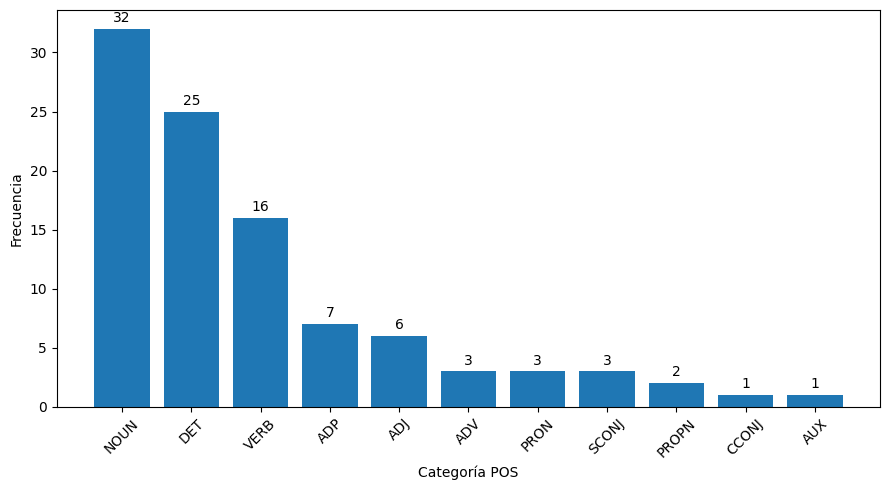

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

barras = plt.bar(
    resumen_pos["POS"],
    resumen_pos["Frecuencia"]
)

plt.xlabel("Categoría POS")
plt.ylabel("Frecuencia")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.3,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "distribucion_pos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Síntesis del análisis

El procesamiento de las trece oraciones permitió obtener información
léxica, morfológica y sintáctica mediante el pipeline de spaCy. El corpus
generó 114 tokens en total y 99 tokens al excluir los signos de puntuación.
Se identificaron 11 categorías POS y 17 tipos de relaciones de dependencia.

Los ejemplos analizados muestran que las etiquetas POS permiten reconocer
la categoría gramatical asignada a cada token, mientras que las relaciones
de dependencia representan su función dentro de la estructura sintáctica.

Los casos que contienen la palabra *banco* muestran que un mismo elemento
léxico puede mantener su categoría gramatical y desempeñar funciones
sintácticas diferentes según el contexto. Asimismo, en la oración
“María observó al profesor con los binoculares”, el analizador vinculó
el complemento “con los binoculares” con el verbo “observó”, seleccionando
una de las estructuras posibles ante una construcción sintácticamente
ambigua.

## Demo interactiva para la defensa

Esta interfaz usa el mismo modelo `es_core_news_sm` del notebook. Se implementa con **Gradio**
para evitar problemas de sincronización de widgets en Google Colab.

Tiene dos pestañas independientes:

- **Ejemplos guardados:** O1, prueba singular→plural, O11, O12 y O13.
- **Escribir mi oración:** permite analizar cualquier oración nueva.

La prueba singular→plural es adicional y no pertenece al corpus original.



In [ ]:
import sys, subprocess, importlib.util
if importlib.util.find_spec("gradio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio>=5.0,<7"])
import gradio as gr



In [ ]:
import html
import pandas as pd
import gradio as gr
from spacy import displacy

try:
    nlp
except NameError:
    import spacy
    nlp = spacy.load("es_core_news_sm")

EJEMPLOS_DEMO = {
    "O1 · La estudiante resuelve el ejercicio.": "La estudiante resuelve el ejercicio.",
    "Prueba · Los estudiantes resuelven los ejercicios.": "Los estudiantes resuelven los ejercicios.",
    "O11 · El banco aprobó el crédito solicitado por la empresa.": "El banco aprobó el crédito solicitado por la empresa.",
    "O12 · Los estudiantes se sentaron en el banco del parque.": "Los estudiantes se sentaron en el banco del parque.",
    "O13 · María observó al profesor con los binoculares.": "María observó al profesor con los binoculares.",
}

def analizar_demo(texto):
    texto = (texto or "").strip()
    columnas = ["Token", "Lema", "POS", "Morfología", "Dependencia", "Núcleo"]

    if not texto:
        return (
            "<div style='background:white;color:#9B1C1C;padding:16px;border-radius:10px;'><b>Escriba o seleccione una oración.</b></div>",
            pd.DataFrame(columns=columnas),
            "",
            ""
        )

    doc = nlp(texto)
    tabla = pd.DataFrame([{
        "Token": t.text,
        "Lema": t.lemma_,
        "POS": t.pos_,
        "Morfología": str(t.morph) if str(t.morph) else "—",
        "Dependencia": t.dep_,
        "Núcleo": t.head.text,
    } for t in doc])

    sin_punt = [t for t in doc if not t.is_punct]
    raices = [t.text for t in doc if t.dep_ == "ROOT"]
    categorias = sorted({t.pos_ for t in sin_punt})

    resumen = f"""
    <div style="background:#fff;color:#073763;border:1px solid #cdebf5;border-radius:14px;padding:16px;font-family:Arial;">
      <div style="font-size:22px;font-weight:700;color:#072F67;">Análisis lingüístico con spaCy</div>
      <div style="font-size:16px;color:#176AA5;margin:5px 0 12px 0;">{html.escape(texto)}</div>
      <div style="display:flex;gap:10px;flex-wrap:wrap;">
        <div style="background:#EAF8FC;border-left:5px solid #10BFE6;border-radius:9px;padding:9px 13px;"><b>Tokens</b><br><span style="font-size:20px;color:#087CC1;">{len(doc)}</span></div>
        <div style="background:#EAF8FC;border-left:5px solid #10BFE6;border-radius:9px;padding:9px 13px;"><b>Sin puntuación</b><br><span style="font-size:20px;color:#087CC1;">{len(sin_punt)}</span></div>
        <div style="background:#EAF8FC;border-left:5px solid #10BFE6;border-radius:9px;padding:9px 13px;"><b>ROOT</b><br><span style="font-size:18px;color:#087CC1;">{html.escape(", ".join(raices) or "—")}</span></div>
        <div style="background:#EAF8FC;border-left:5px solid #10BFE6;border-radius:9px;padding:9px 13px;"><b>POS</b><br><span style="color:#087CC1;">{html.escape(", ".join(categorias))}</span></div>
      </div>
    </div>
    """

    arbol = displacy.render(
        doc, style="dep", jupyter=False,
        options={"compact": True, "distance": 105, "bg": "#FFFFFF", "color": "#073763", "font": "Arial"}
    )
    arbol = f"<div style='background:white;border:1px solid #cdebf5;border-radius:12px;padding:10px;overflow-x:auto'>{arbol}</div>"

    nota = ""
    if any(t.lemma_.lower() == "banco" for t in doc):
        nota = ("**Lectura para la defensa:** \`banco\` conserva una categoría gramatical, "
                "pero la tabla no contiene una etiqueta de sentido como “institución financiera” o “asiento”. "
                "La interpretación depende del contexto.")
    elif "binoculares" in texto.lower():
        nota = ("**Lectura para la defensa:** el parser selecciona una estructura de dependencias, "
                "pero esa salida no elimina otras interpretaciones lingüísticamente posibles.")

    return resumen, tabla, arbol, nota

tema = gr.themes.Soft(primary_hue="blue", secondary_hue="cyan")
css = """
.gradio-container {background:#ffffff !important;color:#073763 !important;}
#titulo-demo {background:linear-gradient(90deg,#063B75,#19AEDA);color:white!important;border-radius:14px;padding:16px 20px;margin-bottom:12px;}
#titulo-demo * {color:white!important;}
footer {display:none!important;}
"""

with gr.Blocks(theme=tema, css=css, title="Demo spaCy") as demo:
    gr.Markdown(
        "# Demo interactiva · POS y dependencias con spaCy\\nUse un ejemplo guardado o escriba una oración propia.",
        elem_id="titulo-demo"
    )

    with gr.Tab("Ejemplos guardados"):
        gr.Markdown("### Seleccione una oración\\nLa oración completa aparece dentro del selector.")
        ejemplo = gr.Dropdown(
            choices=[(k, v) for k, v in EJEMPLOS_DEMO.items()],
            value=EJEMPLOS_DEMO["O1 · La estudiante resuelve el ejercicio."],
            label="Ejemplo"
        )
        btn1 = gr.Button("Analizar ejemplo", variant="primary")
        r1 = gr.HTML()
        t1 = gr.Dataframe(headers=["Token","Lema","POS","Morfología","Dependencia","Núcleo"], interactive=False, wrap=True, label="Resultados por token")
        a1 = gr.HTML()
        n1 = gr.Markdown()
        btn1.click(analizar_demo, inputs=ejemplo, outputs=[r1,t1,a1,n1])

    with gr.Tab("Escribir mi oración"):
        gr.Markdown("### Escriba una oración nueva\\nEsta prueba no modifica el corpus original.")
        libre = gr.Textbox(label="Oración", placeholder="Ejemplo: Los estudiantes analizan los resultados.", lines=3)
        btn2 = gr.Button("Analizar mi oración", variant="primary")
        r2 = gr.HTML()
        t2 = gr.Dataframe(headers=["Token","Lema","POS","Morfología","Dependencia","Núcleo"], interactive=False, wrap=True, label="Resultados por token")
        a2 = gr.HTML()
        n2 = gr.Markdown()
        btn2.click(analizar_demo, inputs=libre, outputs=[r2,t2,a2,n2])

gr.Markdown("**Secuencia sugerida:** O1 → singular/plural → O11 → O12 → O13 → oración nueva opcional.")

demo.launch(share=True, inline=True, debug=False, prevent_thread_lock=True)

